# Naiwny klasyfikator bayesowski – teoria i przykład z Adult (Census Income)

Naiwny klasyfikator bayesowski to prosty, znany algorytm, który przydziela obiekt do takiej klasy, dla której wyliczone `P(klasa|cechy)` jest największe, wykorzystując twierdzenie Bayesa i zakładając niezależność cech (stąd "naiwny").

W tym notebooku:
- najpierw wyjaśniamy ideę algorytmu,
- potem pokazujemy jego implementację,
- a następnie klasyfikujemy na autentycznych, kategorycznych danych (Adult – czy zarabiasz >50k?).

## Twierdzenie Bayesa w klasyfikacji

Twierdzenie Bayesa mówi:

$$
P(K|X) = \frac{P(X|K) \cdot P(K)}{P(X)}
$$

Gdzie:
- $K$ – klasa,
- $X$ – cechy obiektu.

W klasyfikacji **nie musimy liczyć $P(X)$**, bo jest wspólne dla wszystkich klas. Liczymy więc $P(K|X) \propto P(X|K)P(K)$.

Założenie naiwne: cechy są niezależne:
$$
P(X|K) = P(x_1|K) \cdot P(x_2|K) \cdot ... \cdot P(x_n|K)
$$

Wygładzanie Laplace'a – zamiast zera rzadkich kombinacji cech, dajemy im minimalną szansę.

# Opis zbioru danych Adult (Census Income)

Zbiór danych Adult pochodzi z amerykańskiego spisu ludności (Census) i jest powszechnie używany do analizy oraz uczenia maszynowego, zwłaszcza klasyfikacji prognozującej, czy osoba zarabia powyżej 50 tysięcy dolarów rocznie.


## Cel analizy

Predykcja zmiennej `income`, czyli:

- `<=50K` — zarobki mniejsze lub równe 50 tysięcy dolarów rocznie,
- `>50K` — zarobki powyżej 50 tysięcy dolarów rocznie.


## Zbiór cech (atrybutów)

Wersja wykorzystywana w analizie zawiera 8 cech kategorycznych, charakterystycznych i istotnych dla klasyfikacji:

| Nazwa            | Opis                                                      |
|------------------|-----------------------------------------------------------|
| **workclass**     | Typ zatrudnienia (np. prywatny, państwowy, samozatrudnienie, bezrobotny) |
| **education**     | Poziom wykształcenia (np. podstawowe, licealne, wyższe)   |
| **marital_status**| Status cywilny (np. żonaty, kawaler, rozwiedziony)         |
| **occupation**    | Rodzaj wykonywanej pracy (np. technik, urzędnik, sprzedawca)|
| **relationship**  | Relacja osoby do rodziny (np. mąż, żona, niezamężna)       |
| **race**          | Przynależność rasowa (np. biała, czarna, azjatycka)        |
| **sex**           | Płeć (mężczyzna, kobieta)                                  |
| **native_country**| Kraj pochodzenia (np. USA, Meksyk, Kanada)                  |


## Dodatkowe cechy pomijane w analizie

Zbiór oryginalny zawiera także cechy liczbowe takie jak:

- wiek (`age`),
- liczba godzin pracy w tygodniu (`hours_per_week`),
- zysk kapitałowy (`capital_gain`),
- strata kapitałowa (`capital_loss`),
- liczba lat edukacji (`education_num`),
- itp.

W tej analizie skupiamy się wyłącznie na cechach jakościowych (dyskretne wartości), aby wykorzystać naiwnego klasyfikatora bayesowskiego dla cech kategorycznych.


## Charakterystyka zbioru

- Łącznie w oryginalnej wersji jest ok. 48 tys. próbek,
- Dane zawierają informacje demograficzne i ekonomiczne,
- Klasa `income` jest niezrównoważona (więcej osób zarabia <=50K),
- Dane wykorzystuje się do przewidywania poziomu dochodów na podstawie atrybutów społeczno-ekonomicznych.




## Prawdopodobieństwa a priori i a posteriori

Prawdopodobieństwo a priori klasy to **miara, jak często dana klasa pojawia się w całym zbiorze danych**, zanim uwzględnimy dodatkową wiedzę lub cechy obiektu.



### Załóżmy, że mamy dwie klasy:

- **Zielona klasa** z 40 obiektami,
- **Czerwona klasa** z 20 obiektami,

co razem daje 60 obiektów.



<div style="text-align: center;">
  <img src="https://www.statsoft.pl/textbook/graphics/NaiveBayesIntro1.gif" alt="Podział klas bez nowego obiektu" style="max-width: 80%; height: auto;"/>
  <p><em>Podział klas bez nowego obiektu</em></p>
</div>


### Obliczamy prawdopodobieństwa a priori dla obu klas:

$$
P(\text{zielona}) = \frac{40}{60} = \frac{2}{3} \approx 0.6667
$$

$$
P(\text{czerwona}) = \frac{20}{60} = \frac{1}{3} \approx 0.3333
$$
## Obliczanie prawdopodobieństw a posteriori dla nowego obiektu:
<div style="text-align: center; margin-top: 30px;">
  <img src="https://www.statsoft.pl/textbook/graphics/NaiveBayesIntro4.gif" alt="Obliczanie prawdopodobieństw a posteriori dla nowego obiektu" style="max-width: 80%; height: auto;"/>
  <p><em>Podział klas z nowym obiektem</em></p>
</div>

### Nowy obiekt ma 4 najbliższych sąsiadów:

- 3 z nich jest czerwonych,
- 1 z nich jest zielony.



### Na podstawie tego obliczamy prawdopodobieństwa warunkowe \(P(X|K)\):

$$
P(X|\text{zielona}) = \frac{1}{40} = 0.025
$$

$$
P(X|\text{czerwona}) = \frac{3}{20} = 0.15
$$







### Wyliczamy prawdopodobieństwa a posteriori (proporcjonalne):

$$
P(\text{zielona}|X) \propto P(X|\text{zielona}) \times P(\text{zielona}) = 0.025 \times 0.6667 = 0.0167
$$

$$
P(\text{czerwona}|X) \propto P(X|\text{czerwona}) \times P(\text{czerwona}) = 0.15 \times 0.3333 = 0.05
$$



### Normalizujemy, aby suma była równa 1:

\[
S = 0.0167 + 0.05 = 0.0667
\]

$$
P(\text{zielona}|X) = \frac{0.0167}{0.0667} \approx 0.25
$$

$$
P(\text{czerwona}|X) = \frac{0.05}{0.0667} \approx 0.75
$$



### Wniosek:

Nowy obiekt z **75% prawdopodobieństwem należy do klasy czerwonej**, bo jego sąsiedztwo silniej wskazuje tę klasę.

# Implementacja


## Pobranie danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, names=col_names, skipinitialspace=True)

# zostawiamy tylko cechy symboliczne i target (income)
cat_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country'
]
# usuwamy nieznane wartości
df = df[(~df[cat_cols].isin(['?']).any(axis=1)) & (~df['income'].isin(['?']))] 

X = df[cat_cols].values
y = df['income'].values

## Podział na trening/test

In [2]:
from sklearn.model_selection import train_test_split

# dzielimy zbiór na treningowy i testowy (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Rozmiar treningowy: {X_train.shape}, rozmiar testowy: {X_test.shape}")

Rozmiar treningowy: (24129, 8), rozmiar testowy: (6033, 8)


## Implementacja naiwnego Bayesa

In [3]:
class NaiveBayesDiscrete:
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.class_labels, class_counts = np.unique(y, return_counts=True)
        self.class_priors = class_counts / class_counts.sum()  # P(K)
        self.n_features = X.shape[1]
        self.likelihoods = {}  # P(x_j = val | K)

        # dla każdej klasy K i cechy j obliczamy rozkład (z Laplace smoothing)
        for idx, klass in enumerate(self.class_labels):
            idxs = np.where(y == klass)[0]
            X_class = X[idxs]
            self.likelihoods[klass] = []
            for j in range(self.n_features):
                values, counts = np.unique(X[:, j], return_counts=True)
                feat_dict = {}
                V = len(values)
                col_data = X_class[:, j]
                for val in values:
                    cnt = np.sum(col_data == val)
                    # Laplace: (cnt + 1) / (wszystkich w klasie + liczba możliwych wartości)
                    feat_dict[val] = (cnt + 1) / (len(col_data) + V)
                self.likelihoods[klass].append(feat_dict)

    def predict_proba(self, X):
        X = np.array(X)
        proba = []
        for xi in X:
            row_proba = []
            for i, klass in enumerate(self.class_labels):
                prob = self.class_priors[i]
                for j in range(self.n_features):
                    prob *= self.likelihoods[klass][j].get(xi[j], 1e-9)
                row_proba.append(prob)
            row_proba = np.array(row_proba)
            row_proba = row_proba / row_proba.sum()
            proba.append(row_proba)
        return np.array(proba)

    def predict(self, X):
        return self.class_labels[np.argmax(self.predict_proba(X), axis=1)]

## Macierz zależności Cramér’s V

Poniższa macierz przedstawia siłę powiązań między poszczególnymi cechami zbioru Adult (Census Income) oraz z cechą docelową `income`.
Skala wartości Cramér’s V wynosi od 0 (brak zależności) do 1 (silna zależność).

Na wykresie wyświetlona jest **tylko dolna połowa macierzy**, ponieważ macierz jest symetryczna i druga połowa to jej lustrzane odbicie.
Dzięki temu łatwiej zaobserwować, które cechy mają największy wpływ na przewidywaną klasę (np. zarobki powyżej 50K).

Ta analiza pozwala wskazać najbardziej znaczące atrybuty dla modelu klasyfikacyjnego i lepiej zrozumieć strukturę danych.

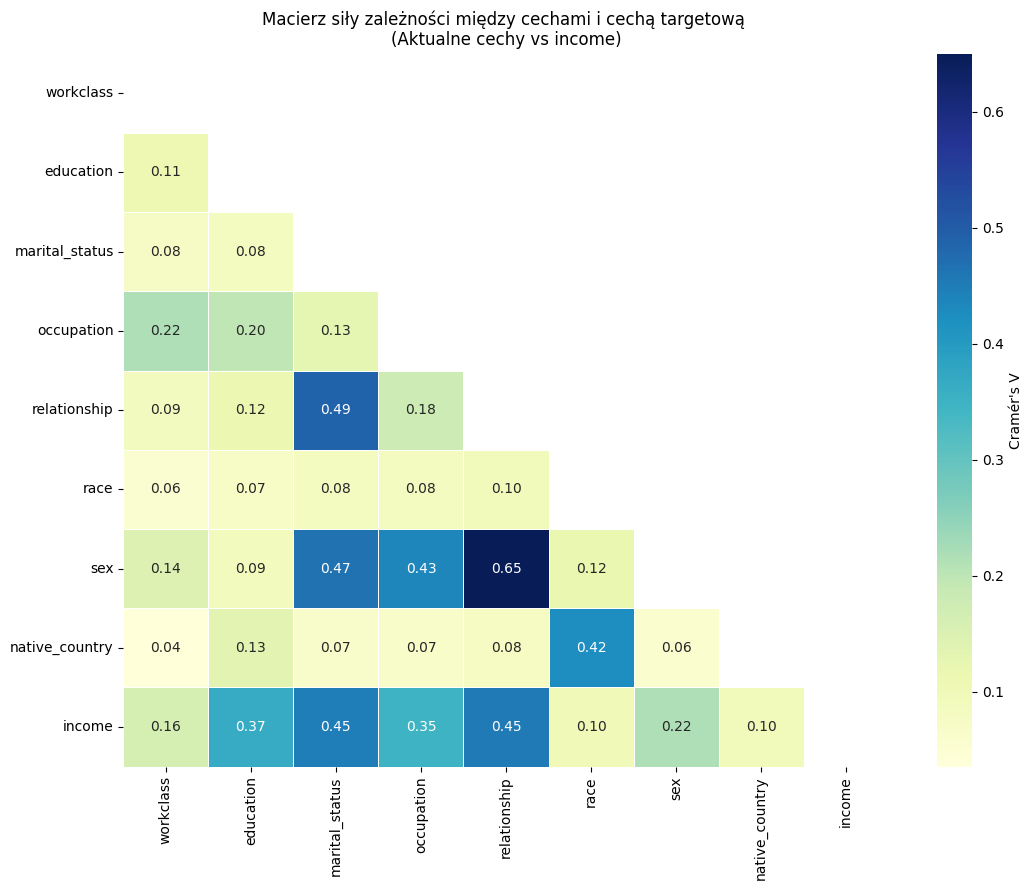

In [4]:
import seaborn as sns
from scipy import stats

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols_with_target = cat_cols + ['income']

corr_list = [
    [cramers_v(df[c1], df[c2]) for c2 in cat_cols_with_target]
    for c1 in cat_cols_with_target
]
corr_df = pd.DataFrame(corr_list, columns=cat_cols_with_target, index=cat_cols_with_target)

# tworzymy maskę do zakrycia górnej połowy macierzy (trójkąt górny)
mask = np.triu(np.ones_like(corr_df, dtype=bool))

plt.figure(figsize=(11,9))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5,
    cbar_kws={"label": "Cramér's V"}
)
plt.title("Macierz siły zależności między cechami i cechą targetową \n(Aktualne cechy vs income)")
plt.tight_layout()
plt.show()

## Uczenie i ocena skuteczności

Dokładność na zbiorze testowym: 0.792


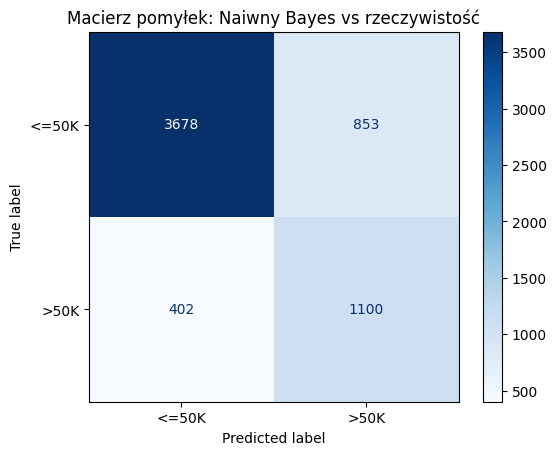

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

clf = NaiveBayesDiscrete()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Dokładność na zbiorze testowym:", round(accuracy_score(y_test, y_pred), 3))

# macierz pomyłek i jej wizualizacja
cm = confusion_matrix(y_test, y_pred, labels=clf.class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.class_labels)
disp.plot(cmap="Blues")
plt.title("Macierz pomyłek: Naiwny Bayes vs rzeczywistość")
plt.show()

## Rozkład prawdopodobieństw dla przykładowych obserwacji

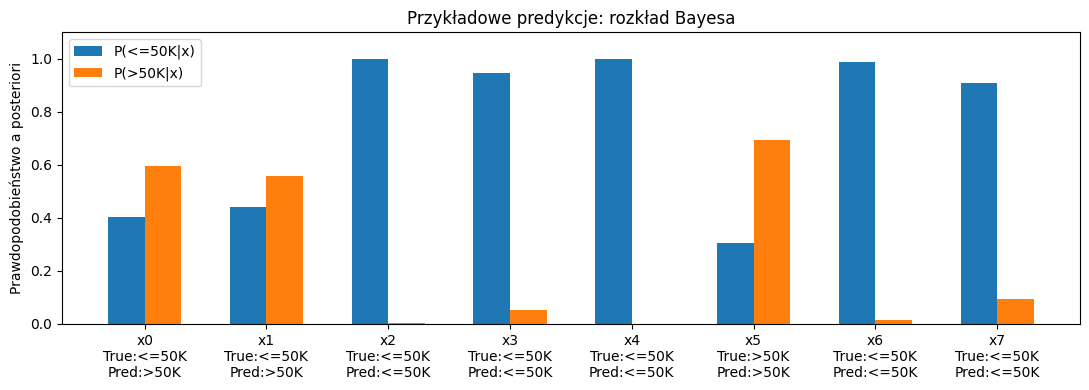

In [6]:
# pokazujemy jak "pewny" jest model dla losowych 8 próbek
np.random.seed(42)
example_idx = np.random.choice(len(X_test), size=8, replace=False)
example_probs = clf.predict_proba(X_test[example_idx])
example_true = y_test[example_idx]
example_pred = y_pred[example_idx]

plt.figure(figsize=(11,4))
width = 0.3
x = np.arange(8)
for i, cl in enumerate(clf.class_labels):
    plt.bar(x+i*width, example_probs[:,i], width=width, label=f"P({cl}|x)")
plt.xticks(x + width * (len(clf.class_labels)-1) / 2, [f"x{i}\nTrue:{t}\nPred:{p}" for i, t, p in zip(range(8), example_true, example_pred)])
plt.ylim([0,1.1])
plt.ylabel("Prawdopodobieństwo a posteriori")
plt.title("Przykładowe predykcje: rozkład Bayesa")
plt.legend()
plt.tight_layout()
plt.show()

## Podsumowanie

- Naiwny klasyfikator bayesowski jest szybki i prosty w implementacji,
- Dobrze działa dla cech kategorycznych,
- Nie wymaga dużych zasob